In [1]:
import numpy as np
import torch
import torch.nn.functional
from e3nn import o3
from matplotlib import pyplot as plt
%matplotlib inline

from mace import data, modules, tools
from mace.tools import torch_geometric

/raid/m.tolloso/miniconda3/envs/mace/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = torch.l

In [8]:
z_table = tools.AtomicNumberTable([1, 8])
atomic_energies = np.array([-1.0, -3.0], dtype=float)
cutoff = 3

model_config = dict(
        num_elements=2,  # number of chemical elements
        atomic_energies=atomic_energies,  # atomic energies used for normalisation
        avg_num_neighbors=8,  # avg number of neighbours of the atoms, used for internal normalisation of messages
        atomic_numbers=z_table.zs,  # atomic numbers, used to specify chemical element embeddings of the model
        r_max=cutoff,  # cutoff
        num_bessel=8,  # number of radial features
        num_polynomial_cutoff=6,  # smoothness of the radial cutoff
        max_ell=2,  # expansion order of spherical harmonic adge attributes
        num_interactions=2,  # number of layers, typically 2
        interaction_cls_first=modules.interaction_classes[
            "RealAgnosticResidualInteractionBlock"
        ],  # interation block of first layer
        interaction_cls=modules.interaction_classes[
            "RealAgnosticResidualInteractionBlock"
        ],  # interaction block of subsequent layers
        hidden_irreps=o3.Irreps("32x0e + 32x1o"),  # 32: number of embedding channels, 0e, 1o is specifying which equivariant messages to use. Here up to L_max=1
        correlation=3,  # correlation order of the messages (body order - 1)
        MLP_irreps=o3.Irreps("16x0e"),  # number of hidden dimensions of last layer readout MLP
        gate=torch.nn.functional.silu,  # nonlinearity used in last layer readout MLP
        
		predict_mve=True,
    )
model = modules.MACE(**model_config)

In [ ]:
print(model)

MACE(
  (node_embedding): LinearNodeEmbeddingBlock(
    (linear): Linear(2x0e -> 32x0e | 64 weights)
  )
  (radial_embedding): RadialEmbeddingBlock(
    (bessel_fn): BesselBasis(r_max=3.0, num_basis=8, trainable=False)
    (cutoff_fn): PolynomialCutoff(p=6, r_max=3.0)
  )
  (spherical_harmonics): SphericalHarmonics()
  (atomic_energies_fn): AtomicEnergiesBlock(energies=[[-1.0000, -3.0000]])
  (interactions): ModuleList(
    (0): RealAgnosticResidualInteractionBlock(
      (linear_up): Linear(32x0e -> 32x0e | 1024 weights)
      (conv_tp): TensorProduct(32x0e x 1x0e+1x1o+1x2e -> 32x0e+32x1o+32x2e | 96 paths | 96 weights)
      (conv_tp_weights): FullyConnectedNet[8, 64, 64, 64, 96]
      (linear): Linear(32x0e+32x1o+32x2e -> 32x0e+32x1o+32x2e | 3072 weights)
      (skip_tp): FullyConnectedTensorProduct(32x0e x 2x0e -> 32x0e+32x1o | 2048 paths | 2048 weights)
      (reshape): reshape_irreps()
    )
    (1): RealAgnosticResidualInteractionBlock(
      (linear_up): Linear(32x0e+32x1o -> 32

In [2]:
from ase.io import read, write
import numpy as np
from matplotlib import pyplot as plt


Number of configs in database:  5000
Number of atoms in each config:  [24 22 25 ... 25 32 40]
Number of atoms in the smallest config:  8
Information stored in config.info: 
 {'Nmols': np.int64(3), 'Comp': 'VC(3)'}
Information stored in config.arrays: 
 dict_keys(['numbers', 'positions', 'molID'])


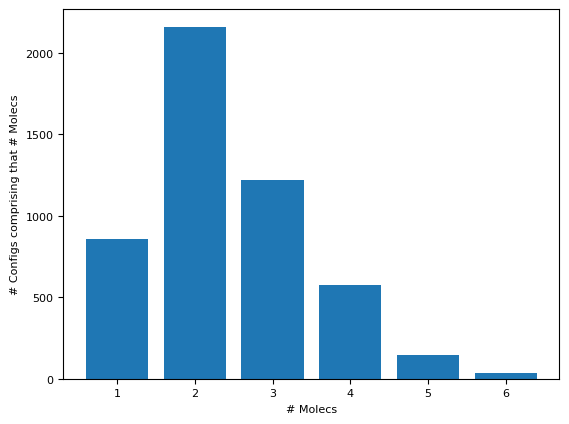

In [ ]:
db = read('test_data/solvent_molecs.xyz', ':') #read in list of configs

print("Number of configs in database: ", len(db))
print("Number of atoms in each config: ", np.array([len(at) for at in db]))
print("Number of atoms in the smallest config: ", np.min([len(at) for at in db])) #test if database contains isolated atoms
print("Information stored in config.info: \n", db[0].info) #check info
print("Information stored in config.arrays: \n", db[0].arrays.keys()) #check arrays

Nmols = np.array([at.info['Nmols'] for at in db]) #collect Nmols information across all data
plt.hist(Nmols, align='left', bins=[1,2,3,4,5,6,7], rwidth=0.8);
plt.xlabel('# Molecs');
plt.ylabel('# Configs comprising that # Molecs');

In [ ]:
from ase import Atoms

db = [Atoms('H'), Atoms('C'), Atoms('O')]+db #add isolated atoms to the database

for at in db[:3]:
    at.info['config_type'] = 'IsolatedAtom'

print("Number of configs in database: ", len(db))

Number of configs in database:  5003


## Energy and forces with xtb

In [ ]:
from tqdm import tqdm
import os
from ase.io import read, write


if not os.path.exists('test_data/solvent_xtb.xyz'):

	from xtb.ase.calculator import XTB
	xtb_calc = XTB(method="GFN2-xTB")

	for at in tqdm(db): #showcase: first 15 frames
		at.calc = xtb_calc
		at.info['energy_xtb'] = at.get_potential_energy()
		at.arrays['forces_xtb'] = at.get_forces()

	write('test_data/solvent_xtb.xyz', db)

db = read('test_data/solvent_xtb.xyz', ':')

print("Information stored in config.info: \n", db[3].info) #check info
print("Information stored in config.arrays: \n", db[3].arrays.keys()) #check arrays


Information stored in config.info: 
 {'Nmols': np.int64(3), 'Comp': 'VC(3)'}
Information stored in config.arrays: 
 dict_keys(['numbers', 'positions', 'molID'])


cos'è molID?

In [2]:
import os
os.makedirs("MACE_tests/mace01/", exist_ok=True)

from mace.cli.eval_configs import main as mace_eval_configs_main
import sys

def eval_mace(configs, model, output):
    sys.argv = ["program", "--configs", configs, "--model", model, "--output", output]
    mace_eval_configs_main()
    
#evaluate the training set
eval_mace(configs="test_data/solvent_xtb_train_200.xyz",
          model="MACE_models_checkpoints/mace01_run-123_stagetwo.model",
          output="MACE_tests/mace01/solvent_train.xyz")

#evaluate the test set
eval_mace(configs="test_data/solvent_xtb_test.xyz",
          model="MACE_models_checkpoints/mace01_run-123_stagetwo.model",
          output="MACE_tests/mace01/solvent_test.xyz")

/raid/m.tolloso/mace/mace/cli/eval_configs.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f=args.model, map_location=args.device)
/raid/m.tolloso/m

### cosa cambia tra i vari models e checkpoint?

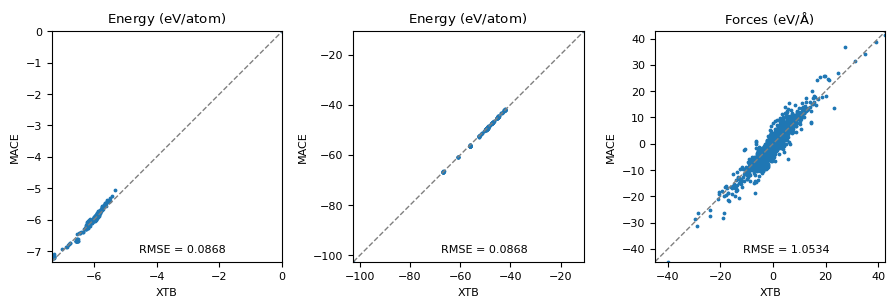

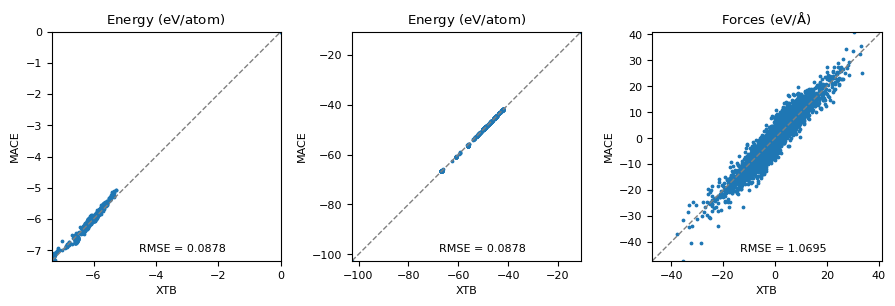

In [11]:
from aseMolec import pltProps as pp
from ase.io import read
import matplotlib.pyplot as plt
from aseMolec import extAtoms as ea
import numpy as np

def plot_RMSEs(db, labs):
    ea.rename_prop_tag(db, 'MACE_energy', 'energy_mace') #Backward compatibility
    ea.rename_prop_tag(db, 'MACE_forces', 'forces_mace') #Backward compatibility

    plt.figure(figsize=(9,6), dpi=100)
    plt.subplot(1,3,1)
    pp.plot_prop(ea.get_prop(db, 'bind', '_xtb', True).flatten(), \
                 ea.get_prop(db, 'bind', '_mace', True).flatten(), \
                 title=r'Energy $(\rm eV/atom)$ ', labs=labs, rel=False)
    plt.subplot(1,3,2)
    pp.plot_prop(ea.get_prop(db, 'info', 'energy_xtb', True).flatten(), \
                 ea.get_prop(db, 'info', 'energy_mace', True).flatten(), \
                 title=r'Energy $(\rm eV/atom)$ ', labs=labs, rel=False)
    plt.subplot(1,3,3)
    pp.plot_prop(np.concatenate(ea.get_prop(db, 'arrays', 'forces_xtb')).flatten(), \
                 np.concatenate(ea.get_prop(db, 'arrays', 'forces_mace')).flatten(), \
                 title=r'Forces $\rm (eV/\AA)$ ', labs=labs, rel=False)
    plt.tight_layout()
    return

train_data = read('MACE_tests/mace01/solvent_train.xyz', ':')
test_data = train_data[:3]+read('MACE_tests/mace01/solvent_test.xyz', ':') #append the E0s for computing atomization energy errors

plot_RMSEs(train_data, labs=['XTB', 'MACE'])
plot_RMSEs(test_data, labs=['XTB', 'MACE'])

/raid/m.tolloso/miniconda3/envs/mace/lib/python3.11/site-packages/ase/ga/__init__.py:25: FutureWarning: The ase.ga code has moved to a separate project, ase_ga:
https://github.com/dtu-energy/ase-ga .
Please install it using e.g. pip install ase-ga.
Please import from ase_ga what would previously be imported from ase.ga.
ase.ga placeholders will be removed in a future release.

  warnings.warn(msg, FutureWarning)


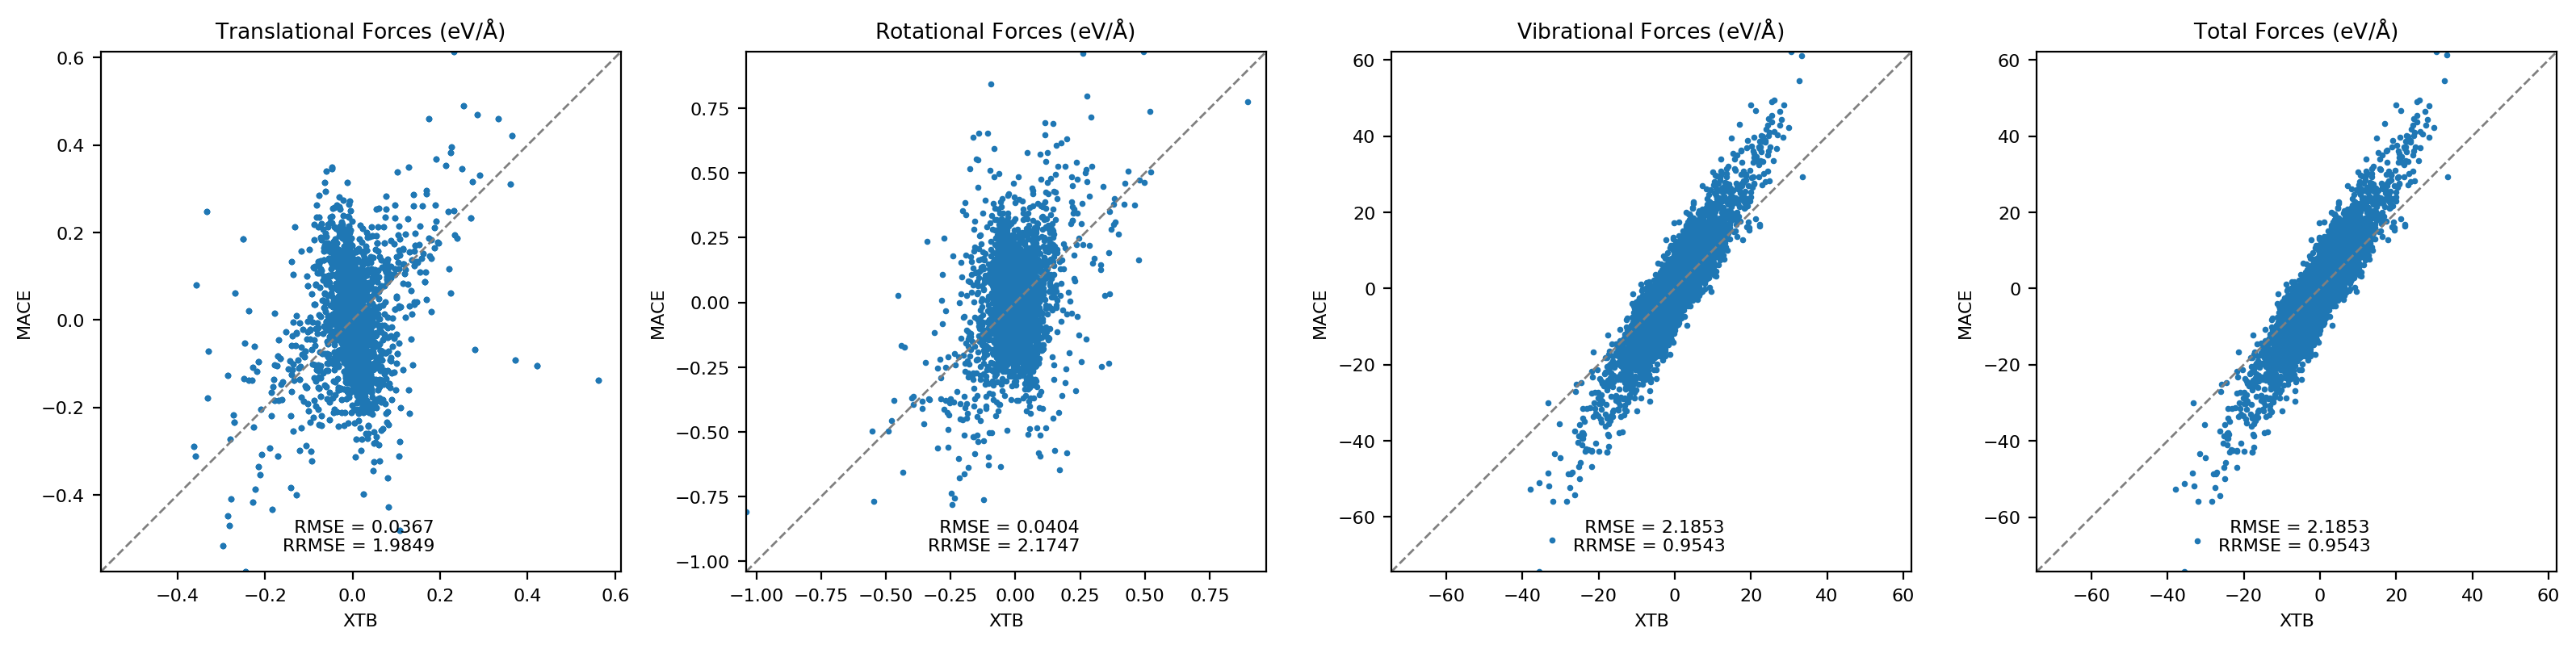

In [4]:
from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa
from aseMolec import extAtoms as ea


db1 = read('MACE_tests/mace01/solvent_test.xyz', ':')
ea.rename_prop_tag(db1, 'energy_xtb', 'energy') #Backward compatibility
ea.rename_prop_tag(db1, 'forces_xtb', 'forces') #Backward compatibility

db2 = read('MACE_tests/mace01/solvent_test.xyz', ':')
ea.rename_prop_tag(db2, 'MACE_energy', 'energy') #Backward compatibility
ea.rename_prop_tag(db2, 'MACE_forces', 'forces') #Backward compatibility

aa.extract_molecs(db1, intra_inter=True)
aa.extract_molecs(db2, intra_inter=True)

pp.plot_trans_rot_vib(db1, db2, labs=['XTB', 'MACE'])

In [12]:
train_data[0].info

{'config_type': 'IsolatedAtom',
 'energy_xtb': np.float64(-10.707211383396714),
 'energy_mace': np.float64(-10.707211383396714),
 'energy_mace_logvar': np.float64(1.5563962095364836),
 'energy_mace_var': np.float64(4.741702315562017),
 'energy_mace_std': np.float64(2.177545020329549)}

In [28]:
import numpy as np

def get_pred_energy_and_sigma(db, prefix="MACE_"):
    """
    Returns:
      mu: shape [n_structures]
      sigma: shape [n_structures] or None if not present
    """
    mu = np.array([at.info[prefix + "energy_mace"] for at in db], dtype=float)

    # Preferred: std
    if all((prefix + "energy_mace_std") in at.info for at in db):
        sigma = np.array([at.info[prefix + "energy_mace_std"] for at in db], dtype=float)
        return mu, sigma

    # Fallback: var
    if all((prefix + "energy_mace_var") in at.info for at in db):
        var = np.array([at.info[prefix + "energy_mace_var"] for at in db], dtype=float)
        sigma = np.sqrt(np.clip(var, 0.0, None))
        return mu, sigma

    # Fallback: logvar
    if all((prefix + "energy_mace_logvar") in at.info for at in db):
        logvar = np.array([at.info[prefix + "energy_mace_logvar"] for at in db], dtype=float)
        sigma = np.sqrt(np.exp(logvar))
        return mu, sigma

    return mu, None

import matplotlib.pyplot as plt

def plot_error_vs_sigma(db, labs, prefix="MACE_"):
	# y_true: XTB energy (your current usage)
	y_true = np.array([at.info["energy_xtb"] for at in db], dtype=float)

	# y_pred: MACE mean + sigma
	y_pred, sigma = get_pred_energy_and_sigma(db, prefix=prefix)
	if sigma is None:
		print("No uncertainty found in Atoms.info; cannot plot error vs sigma.")
		return

	err = np.abs(y_true - y_pred)

	# Compute correlation coefficient
	corr = np.corrcoef(sigma, err)[0, 1]

	plt.figure(figsize=(6,5), dpi=100)
	plt.scatter(sigma, err, s=12, alpha=0.6)
	# Plot bisector (y=x)
	# xlim = plt.xlim()
	# ylim = plt.ylim()
	# min_lim = min(xlim[0], ylim[0])
	# max_lim = max(xlim[1], ylim[1])
	# plt.plot([min_lim, max_lim], [min_lim, max_lim], 'r--', label='y = x')
	# plt.xlim(xlim)
	# plt.ylim(ylim)
	plt.xlabel(r"Predicted $\sigma_E$ (eV)")
	plt.ylabel(r"Absolute error $|E_{\rm ref}-\mu|$ (eV)")
	plt.title("Energy error vs predicted uncertainty")
	plt.legend()
	# Annotate correlation
	plt.text(0.05, 0.95, f"corr = {corr:.2f}", transform=plt.gca().transAxes,
			 fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round", fc="w", ec="0.5"))
	plt.tight_layout()

def plot_coverage(db, prefix="MACE_", ks=(0.5, 1.0, 1.5, 2.0, 2.5, 3.0)):
    y_true = np.array([at.info["energy_xtb"] for at in db], dtype=float)
    y_pred, sigma = get_pred_energy_and_sigma(db, prefix=prefix)
    if sigma is None:
        print("No uncertainty found in Atoms.info; cannot plot coverage.")
        return

    # Avoid division issues
    sigma = np.maximum(sigma, 1e-12)

    z = np.abs(y_true - y_pred) / sigma  # standardized absolute error

    empirical = np.array([(z <= k).mean() for k in ks])

    # Expected coverage for N(0,1): P(|Z|<=k) = erf(k/sqrt(2))
    from math import erf, sqrt
    expected = np.array([erf(k / sqrt(2.0)) for k in ks])

    plt.figure(figsize=(6,5), dpi=100)
    plt.plot(ks, empirical, marker="o", label="Empirical")
    plt.plot(ks, expected, marker="o", label="Expected (Gaussian)")
    plt.xlabel(r"$k$ in $\pm k\sigma$")
    plt.ylabel("Coverage fraction")
    plt.ylim(0, 1.02)
    plt.title("Uncertainty calibration (coverage)")
    plt.legend()
    plt.tight_layout()


In [6]:
print(train_data[3].info)

{'Nmols': np.int64(3), 'Comp': 'VC(3)', 'energy_xtb': np.float64(-1602.093208085042), 'energy_mace': np.float64(-1600.56544657206), 'energy_mace_logvar': np.float64(7.776392706681044), 'energy_mace_var': np.float64(2383.6607296772995), 'energy_mace_std': np.float64(48.8227480758437)}


/tmp/ipykernel_3982300/3187133045.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


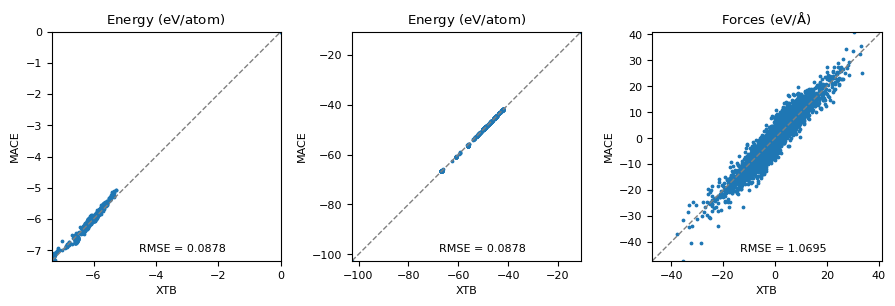

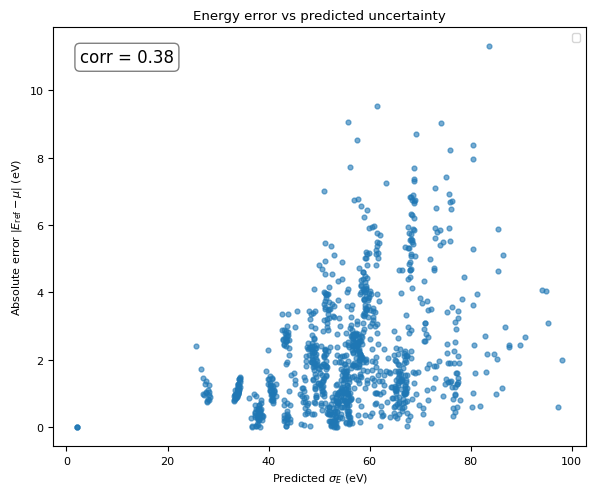

In [29]:
# plot_RMSEs(train_data, labs=['XTB', 'MACE'])
# plot_error_vs_sigma(train_data, labs=['XTB', 'MACE'], prefix="")
# plot_coverage(train_data, prefix="")

plot_RMSEs(test_data, labs=['XTB', 'MACE'])
plot_error_vs_sigma(test_data, labs=['XTB', 'MACE'], prefix="")
# plot_coverage(test_data, prefix="")
# Optional:
# plot_energy_parity_with_errorbars(test_data, labs=['XTB', 'MACE'], prefix="MACE_")
